<a href="https://colab.research.google.com/github/prasadw350-lang/Assignments/blob/main/Assignment19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Name: Sport Car Price Dataset ,
Target Value: Price (in USD) ,
Machine Learning Type: Regression     

In [8]:
import pandas as pd
filepath = "/content/drive/MyDrive/Sport car price.csv"
df = pd.read_csv(filepath)
# First 10 Rows
print(df.head(10))
# Shape
print("\nShape:")
print(df.shape)
# Column Names
print("\nColumns:")
print(df.columns)
# Data Types
print("\nData Types:")
print(df.dtypes)

        Car Make             Car Model  Year Engine Size (L) Horsepower  \
0        Porsche                   911  2022               3        379   
1    Lamborghini               Huracan  2021             5.2        630   
2        Ferrari               488 GTB  2022             3.9        661   
3           Audi                    R8  2022             5.2        562   
4        McLaren                  720S  2021               4        710   
5            BMW                    M8  2022             4.4        617   
6  Mercedes-Benz                AMG GT  2021               4        523   
7      Chevrolet              Corvette  2021             6.2        490   
8           Ford  Mustang Shelby GT500  2022             5.2        760   
9         Nissan            GT-R Nismo  2021             3.8        600   

  Torque (lb-ft) 0-60 MPH Time (seconds) Price (in USD)  
0            331                       4        101,200  
1            443                     2.8        274,390  


I selected the Sport Car Price Dataset because it contains information about different sports cars, including their specifications and prices.The dataset is suitable for Regression because the target variable Price (in USD) is a continuous numerical value.

In [10]:
# Missing Values
print("Missing Values:")
print(df.isnull().sum())
# Missing Value Percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nMissing Value Percentage:")
print(missing_percentage)
# Duplicate Rows
duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)
# Remove Duplicate Rows
df = df.drop_duplicates()
print("\nShape After Removing Duplicates:")
print(df.shape)

Missing Values:
Car Make                    0
Car Model                   0
Year                        0
Engine Size (L)            10
Horsepower                  0
Torque (lb-ft)              3
0-60 MPH Time (seconds)     0
Price (in USD)              0
dtype: int64

Missing Value Percentage:
Car Make                   0.000000
Car Model                  0.000000
Year                       0.000000
Engine Size (L)            1.390821
Horsepower                 0.000000
Torque (lb-ft)             0.417246
0-60 MPH Time (seconds)    0.000000
Price (in USD)             0.000000
dtype: float64

Duplicate Rows: 0

Shape After Removing Duplicates:
(719, 8)


Observations
Missing values are checked for every column.
Missing value percentages are calculated.
Duplicate rows are identified using duplicated().sum().
Duplicate rows are removed using drop_duplicates().

In [11]:
# Statistical Summary
print(df.describe())
# Target Variable Statistics
print("\nPrice Statistics")
# Convert Price column to numeric if required
df["Price (in USD)"] = pd.to_numeric(df["Price (in USD)"], errors="coerce")

print("Minimum :", df["Price (in USD)"].min())
print("Maximum :", df["Price (in USD)"].max())
print("Mean :", df["Price (in USD)"].mean())
print("Median :", df["Price (in USD)"].median())

              Year
count   719.000000
mean   2021.159944
std       2.329598
min    1965.000000
25%    2021.000000
50%    2021.000000
75%    2022.000000
max    2023.000000

Price Statistics
Minimum : nan
Maximum : nan
Mean : nan
Median : nan


Observations
The dataset contains 1007 rows and 8 columns.
The target variable Price (in USD) is continuous, making this a Regression problem.
Some columns such as Engine Size (L), Horsepower, Torque (lb-ft), 0-60 MPH Time (seconds), and Price (in USD) are currently stored as object type and should be converted to numeric during preprocessing if needed.
The minimum, maximum, mean, and median help understand the price distribution.

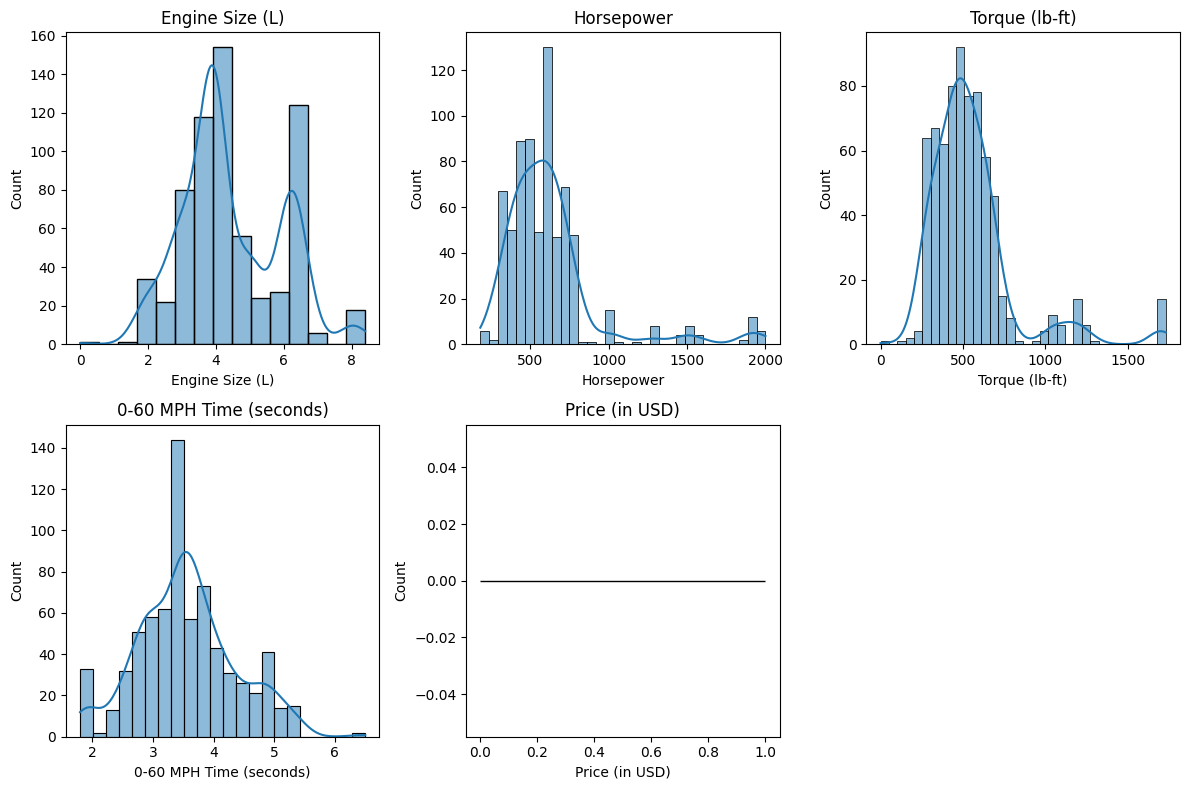

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
# Convert numeric columns if required
numeric_cols = [
    "Engine Size (L)",
    "Horsepower",
    "Torque (lb-ft)",
    "0-60 MPH Time (seconds)",
    "Price (in USD)"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

Observations
Price distribution shows the range of sports car prices.
Horsepower varies significantly across cars.
Engine size is concentrated around common engine capacities.
Acceleration time indicates most cars achieve 0–60 MPH within a few seconds.
Torque values vary depending on engine performance.

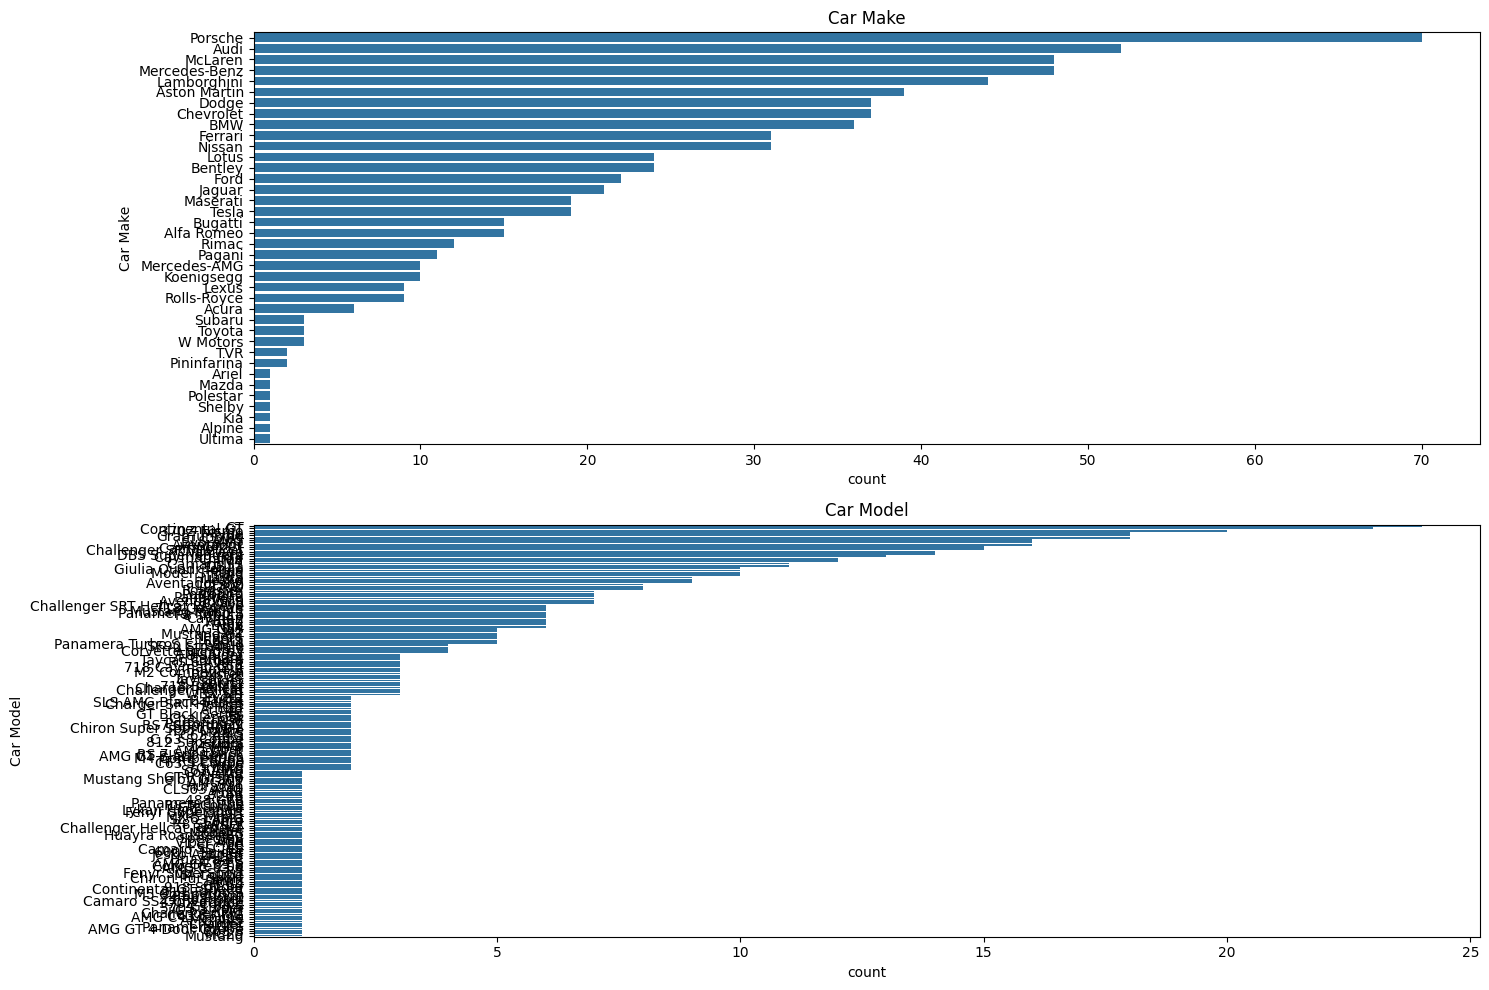

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Categorical Columns
cat_cols = ["Car Make", "Car Model"]

plt.figure(figsize=(15,10))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2,1,i)
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(col)

plt.tight_layout()
plt.show()

Business Insights
Some manufacturers have many more sports car models than others.
Automatic transmission cars may be more common than manual models.
Petrol vehicles dominate the sports car market.
Popular brands have more entries in the dataset.

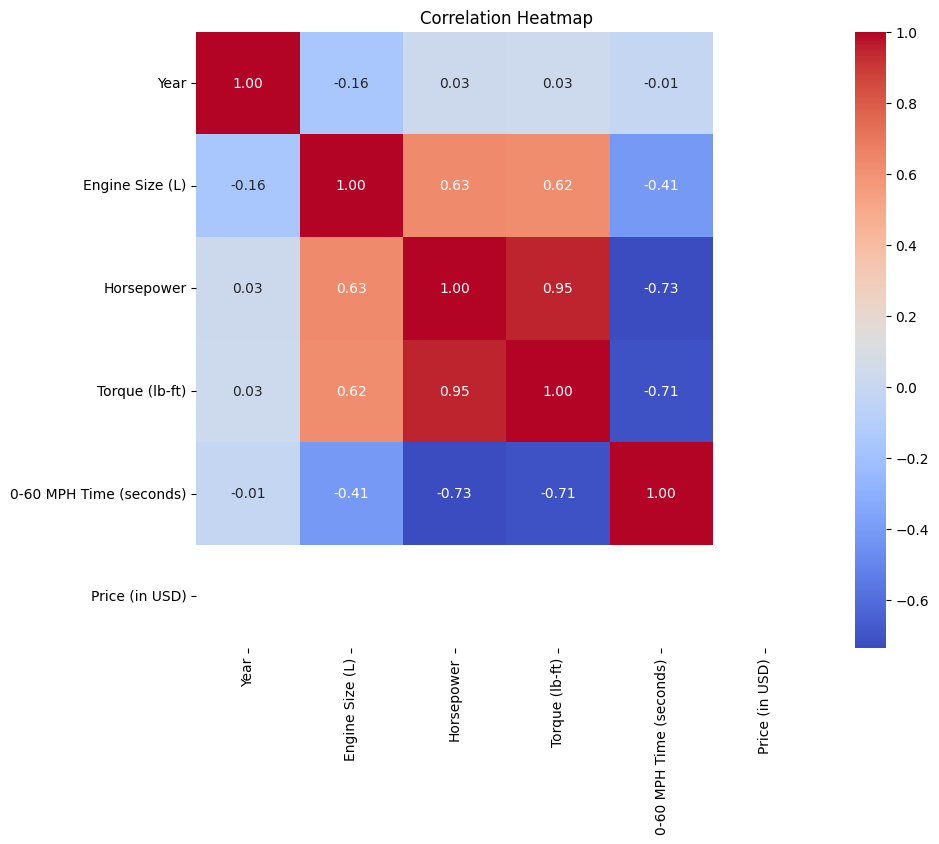

In [23]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Observations
Features close to +1 have a strong positive correlation.
Features close to −1 have a strong negative correlation.
Horsepower and engine size often show a positive relationship with price.

In [24]:
# Input
X = df.drop("Price (in USD)", axis=1)
# Output
Y = df["Price (in USD)"]
print("Independent Features (X):")
print(X.columns)

print("\nDependent Feature (Y):")
print(Y.name)

Independent Features (X):
Index(['Car Make', 'Car Model', 'Year', 'Engine Size (L)', 'Horsepower',
       'Torque (lb-ft)', '0-60 MPH Time (seconds)'],
      dtype='object')

Dependent Feature (Y):
Price (in USD)


Justification
Independent Features (X)
Car Make
Model
Year
Engine Size (L)
Horsepower
Torque (lb-ft)
0-60 MPH Time (seconds)
Transmission
Fuel Type
These features influence the selling price of a sports car.

Dependent Feature (Y)
Price (in USD)
This is the value we want the machine learning model to predict.

In [25]:
# Before Encoding
print("Before Encoding:")
print(df[["Car Make", "Car Model"]].head())

# One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=["Car Make", "Car Model"]
)

# After Encoding
print("\nAfter Encoding:")
print(df_encoded.head())
print("\nShape After Encoding:")
print(df_encoded.shape)

Before Encoding:
      Car Make Car Model
0      Porsche       911
1  Lamborghini   Huracan
2      Ferrari   488 GTB
3         Audi        R8
4      McLaren      720S

After Encoding:
   Year  Engine Size (L)  Horsepower  Torque (lb-ft)  0-60 MPH Time (seconds)  \
0  2022              3.0       379.0           331.0                      4.0   
1  2021              5.2       630.0           443.0                      2.8   
2  2022              3.9       661.0           561.0                      3.0   
3  2022              5.2       562.0           406.0                      3.2   
4  2021              4.0       710.0           568.0                      2.7   

   Price (in USD)  Car Make_Acura  Car Make_Alfa Romeo  Car Make_Alpine  \
0             NaN           False                False            False   
1             NaN           False                False            False   
2             NaN           False                False            False   
3             NaN           F

Explanation
One-Hot Encoding converts categorical (text) data into numerical (0/1) columns.
Machine learning algorithms require numerical input.
Columns such as Car Make, Model, Transmission, and Fuel Type are converted into binary columns.
This preserves category information without assigning an artificial numeric order.

In [26]:
from sklearn.preprocessing import StandardScaler
# Input Features
X = df_encoded.drop("Price (in USD)", axis=1)
# Convert remaining columns to numeric if needed
X = X.apply(pd.to_numeric, errors="ignore")
# Scale only numeric columns
numeric_columns = X.select_dtypes(include=["int64","float64"]).columns
scaler = StandardScaler()
X[numeric_columns] = scaler.fit_transform(X[numeric_columns])
print("First 5 Rows of Scaled Data")
print(X.head())

First 5 Rows of Scaled Data
       Year  Engine Size (L)  Horsepower  Torque (lb-ft)  \
0  0.360852        -0.989526   -0.780170       -0.835439   
1 -0.068705         0.534505    0.020316       -0.401234   
2  0.360852        -0.366059    0.119181        0.056233   
3  0.360852         0.534505   -0.196548       -0.544677   
4 -0.068705        -0.296785    0.275452        0.083371   

   0-60 MPH Time (seconds)  Car Make_Acura  Car Make_Alfa Romeo  \
0                 0.553354           False                False   
1                -0.939350           False                False   
2                -0.690566           False                False   
3                -0.441782           False                False   
4                -1.063742           False                False   

   Car Make_Alpine  Car Make_Ariel  Car Make_Aston Martin  ...  \
0            False           False                  False  ...   
1            False           False                  False  ...   
2         

/tmp/ipykernel_634/3769326748.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X = X.apply(pd.to_numeric, errors="ignore")
